In [1]:

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import matplotlib.path as mpath
from matplotlib.patches import Ellipse
from scipy.odr import ODR, Model, Data
from scipy import constants
from scipy.stats import spearmanr

from astropy.io import fits
from astropy.wcs import WCS
from astropy.convolution import Gaussian2DKernel, convolve


In [2]:
SAVE_FIGS = True

#GDIGS Only
L_BOUNDS = [16.26, 32.26] # degrees
B_BOUNDS = [-1.46, 1.44] # degrees

# L_BOUNDS = [40, 60] # degrees
# B_BOUNDS = [-1.46, 1.44] # degrees

# LINUX_DIRECTORY = '/home/aimee/mphys' # Aimee
LINUX_DIRECTORY = '/home/u20482jg/MPHYS_Project_Local' # Joe
# MAPS_DIRECTORY = f'{LINUX_DIRECTORY}/data/maps' # Aimee
MAPS_DIRECTORY = f'{LINUX_DIRECTORY}/data/all_maps/maps' # Joe

# FIGURE_SAVEDIR = f'{LINUX_DIRECTORY}/figures' # Aimee
FIGURE_SAVEDIR = f'{LINUX_DIRECTORY}/figures/difference_maps' # Joe

TTRESPREFIX = f"{LINUX_DIRECTORY}/results_files/longitude_intercept_fits/TT_Plots_for_2.0x3.0_degree_rectangles_-_"
THEORVALSPREFIX = f"{LINUX_DIRECTORY}/results_files/GDIGS_Theoretical_values/Theoretical_gradients"


COMAP_ERR = 0.05
EFFELSBERG_ERR = 0.1
GDIGS_ERR = 0.1 # TEMP - CHECK!
NOBEYAMA_ERR = 0.1 # TEMP
PARKES_ERR = 0.1 # TEMP
SINO_GERMAN_ERR = 0.1 # TEMP
AKARI_ERR = 0.1 # TEMP


COMAP_FWHM = 4.5
EFFELSBERG_FWHM = 4.9999
GDIGS_FWHM = 2.65 # TEMP
NOBEYAMA_FWHM = 4.9999 # TEMP
PARKES_FWHM = 4.9999 # TEMP
SINO_GERMAN_FWHM = 9.9999 # TEMP
AKARI_FWHM = 4.9999 # TEMP


# Pixel coordinate fudges (arcmin)
GDIGS_FUDGEFACTORs = [0,0]
# COMAP_FUDGEFACTORs = [-3,1]
# GDIGS_FUDGEFACTORs = [0,0]
COMAP_FUDGEFACTORs = [0,0]


COMAP_MAPS = { # name : [file name, frequency / Hz]
    "COMAP 26.5 GHz" : ["comap_alr-2_galactic_301025_band00_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 26.5e9],
    "COMAP 27.5 GHz" : ["comap_alr-2_galactic_301025_band01_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 27.5e9],
    "COMAP 28.5 GHz" : ["comap_alr-2_galactic_301025_band02_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 28.5e9],
    "COMAP 29.5 GHz" : ["comap_alr-2_galactic_301025_band03_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 29.5e9],
    "COMAP 30.5 GHz" : ["comap_alr-2_galactic_301025_band04_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 30.5e9],
    "COMAP 31.5 GHz" : ["comap_alr-2_galactic_301025_band05_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 31.5e9],
    "COMAP 32.5 GHz" : ["comap_alr-2_galactic_301025_band06_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 32.5e9],
    "COMAP 33.5 GHz" : ["comap_alr-2_galactic_301025_band07_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 33.5e9]
}

# User guide: https://eff100mwiki.mpifr-bonn.mpg.de/doku.php?id=information_for_astronomers:user_guide:index
EFFELSBERG_MAPS = { # name : [file name, frequency / Hz]
    # "Effelsberg 1.43 GHz (10')" : ["EFFELSBERG-1.4285714285714286GHz-10.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (15')" : ["EFFELSBERG-1.4285714285714286GHz-15.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (20')" : ["EFFELSBERG-1.4285714285714286GHz-20.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (25')" : ["EFFELSBERG-1.4285714285714286GHz-25.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (30')" : ["EFFELSBERG-1.4285714285714286GHz-30.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (60')" : ["EFFELSBERG-1.4285714285714286GHz-60.0amin.fits", 1.4285714285714286e9],
    "Effelsberg 2.73 GHz (5 amin)" : ["EFFELSBERG-2.7272727272727275GHz-5.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (10')" : ["EFFELSBERG-2.7272727272727275GHz-10.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (15')" : ["EFFELSBERG-2.7272727272727275GHz-15.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (20')" : ["EFFELSBERG-2.7272727272727275GHz-20.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (25')" : ["EFFELSBERG-2.7272727272727275GHz-25.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (30')" : ["EFFELSBERG-2.7272727272727275GHz-30.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (60')" : ["EFFELSBERG-2.7272727272727275GHz-60.0amin.fits", 2.7272727272727275e9]
}

GDIGS_MAPS = { # name : [file name, frequency / Hz]
    # Note to self: create a GDIGS mosaic smoothed to 5 arcmin?
    "GDIGS Moment 0" : ["gdigs_moment0_mosaic_1arcmin.fits", 5.76e9] # CHECK GDIGS FREQUENCY
}

NOBEYAMA_MAPS = { # name : [file name, frequency / Hz]
    "Nobeyama 10.0GHz (5 amin)" : ["NOBEYAMA-10.0GHz-5.0amin.fits", 10.3e9]
    # "Nobeyama 10.0GHz (10 amin)"  : ["NOBEYAMA-10.0GHz-10.0amin.fits", 9.4e9]
}

PARKES_MAPS = { # name : [file name, frequency / Hz]
    # "PARKES 5GHz (5')" : ["PARKES-5.0GHz-5.0amin.fits", 5e9], # CORRUPTED
    "PARKES 5GHz (10')" : ["PARKES-5.0GHz-10.0amin.fits", 5e9]
}


SINO_GERMAN_MAPS = { # name : [file name, frequency / Hz]
    "Sino German 5.0GHz (10 amin)" : ["SinoGermanSurvey-5.0GHz-10.0amin.fits", 5e9]
}

AKARI_MAPS = { # name : [file name, frequency / Hz]
    "Akari 1875 GHz (5 amin)" : ["AKARI-1874.9999999999998GHz-5.0amin.fits", 1874.9999999999998e9],
    # "Akari 1875 GHz (10')" : ["AKARI-1874.9999999999998GHz-10.0amin.fits", 1874.9999999999998e9],
    # "Akari 2143 GHz (5 amin)" : ["AKARI-2142.857142857143GHz-5.0amin.fits", 2142.857142857143e9],
    "Akari 2143 GHz (10')" : ["AKARI-2142.857142857143GHz-10.0amin.fits", 2142.857142857143e9],
    # "Akari 3333 GHz (5 amin)" : ["AKARI-3333.333333333333GHz-5.0amin.fits", 3333.333333333333e9],
    "Akari 3333 GHz (10')" : ["AKARI-3333.333333333333GHz-10.0amin.fits", 3333.333333333333e9],
    # "Akari 4615 GHz (5 amin)" : ["AKARI-4615.384615384616GHz-5.0amin.fits", 4615.384615384616e9],
    "Akari 4615 GHz (10')" : ["AKARI-4615.384615384616GHz-10.0amin.fits", 4615.384615384616e9]
}

AMI_MAPS = {}

BOLOCAM_MAPS = {} # CORRUPTED

CGPS_MAPS = {} # CORRUPTED

CHIPASS_MAPS = {}

IRIS_MAPS = {}

PLANCKHFI_MAPS = {
    "PLANCK HFI 217 GHZ (5 amin)": "PLANCK HFI-217.0GHz-5.0amin.fits"
}

# Main functions

def get_map(path):
    
    # print(f"\nGetting data from {path}")
    fits_file = fits.open(path)

    data = fits_file[0].data
    header = fits_file[0].header
    if path == f"{MAPS_DIRECTORY}/comap_160625_band00_band00_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits":
        header['CRVAL2'] += 0.5/60
        # header['LONPOLE'] = 180.0

    wcs = WCS(header)

    return data, header, wcs


def get_map_info(map_title):
    
    if map_title in COMAP_MAPS.keys():
        fname = COMAP_MAPS[map_title][0]
        freq = COMAP_MAPS[map_title][1]
        fwhm = COMAP_FWHM
        err = COMAP_ERR
    elif map_title in EFFELSBERG_MAPS.keys():
        fname = EFFELSBERG_MAPS[map_title][0]
        freq = EFFELSBERG_MAPS[map_title][1]
        fwhm = EFFELSBERG_FWHM
        err = EFFELSBERG_ERR
    elif map_title in GDIGS_MAPS.keys():
        fname = GDIGS_MAPS[map_title][0]
        freq = GDIGS_MAPS[map_title][1]
        fwhm = GDIGS_FWHM
        err = GDIGS_ERR
    elif map_title in NOBEYAMA_MAPS.keys():
        fname = NOBEYAMA_MAPS[map_title][0]
        freq = NOBEYAMA_MAPS[map_title][1]
        fwhm = NOBEYAMA_FWHM # FIND OUT!
        err = NOBEYAMA_ERR # FIND OUT!
    elif map_title in PARKES_MAPS.keys():
        fname = PARKES_MAPS[map_title][0]
        freq = PARKES_MAPS[map_title][1]
        fwhm = PARKES_FWHM # FIND OUT!
        err = PARKES_ERR # FIND OUT!
    elif map_title in SINO_GERMAN_MAPS.keys():
        fname = SINO_GERMAN_MAPS[map_title][0]
        freq = SINO_GERMAN_MAPS[map_title][1]
        fwhm = SINO_GERMAN_FWHM # FIND OUT!
        err = SINO_GERMAN_ERR # FIND OUT!
    elif map_title in AKARI_MAPS.keys():
        fname = AKARI_MAPS[map_title][0]
        freq = AKARI_MAPS[map_title][1]
        fwhm = AKARI_FWHM # FIND OUT!
        err = AKARI_ERR # FIND OUT!
    
    # (ADD MORE MAPS AS NECESSARY)
    
    else:
        print(f'Error extracting map details for {map_title}')
        return None, None, None, None

    return fname, freq, fwhm, err


def JyPersr_to_K(inp, freq):
    
    k_B = constants.Boltzmann
    c = constants.speed_of_light
    Jy_to_SI = 1e-26

    factor = (c**2) / (2 * k_B * (freq**2)) * Jy_to_SI
    
    return factor * inp


def convert_to_mK(map_title, map, map_freq):
    
    # COMAP and GDIGS in K
    if map_title in COMAP_MAPS.keys():
        print("COMAP conversion detected")
        map_mK = np.array(map) * 1000 # K to mK
    
    # elif map_title in GDIGS_MAPS.keys():
    #     map_mK = intrrl_to_cont(np.array(map), map_freq, ELECTRON_TEMP) * 1000
    elif map_title in GDIGS_MAPS.keys():
        print("GDIGS conversion detected")
        map_mK = np.array(map) * 1000 # K to mK
        # map_mjysr = np.array(map) * 10**3 / 2 / GDIGS_FWHM
        # # map_mK = JyPersr_to_K(np.array(map_mjysr), map_freq) # Jy/sr to K
        # return map_mjysr

    
    # All other maps in Jy/sr (CHECK WHENEVER ADD NEW MAPS!)
    else: 
        print("Other conversion detected")
        map_K = JyPersr_to_K(np.array(map), map_freq) # Jy/sr to K
        map_mK = np.array(map_K) * 1000 # K to mK
    
    return map_mK


def remove_nans(array_of_arrays): # array_of_arrays in form [np.array(a1), np,array(a2), etc.]
    
    mask = np.any([np.isnan(array) for array in array_of_arrays], axis=0)
    
    return tuple(array[~mask] for array in array_of_arrays)


def galactic_to_pixel(l_coords, b_coords, WCS):

    x_coords = []
    y_coords = []
    for i, _ in enumerate(l_coords):
        l = l_coords[i] 
        b = b_coords[i]
        
        x, y = WCS.all_world2pix(float(l), float(b), 0)

        x_coords.append(x)
        y_coords.append(y)

    return x_coords, y_coords


def plot_fits(fits_data, projection, x_coords=[], y_coords=[],
              contour_map=None, n_contours=0, perc_ranges=(0.0, 99.5),
              decorators=None, decorator_locs=None,
              title='Title', save_figs=SAVE_FIGS): # modified from jg_notebooks/gp_plotting.ipynb
    
    y_poscorr = 0
    x_poscorr = 2
    
    fits_data = np.where(fits_data == hp.UNSEEN, np.nan, fits_data) # convert hp.UNSEEN to np.nan for plotting
    
    vmin = -np.nanpercentile(fits_data, 99.5) #0.0 #np.nanpercentile(fits_data, 0.)
    vmax = np.nanpercentile(fits_data, 99.5)

    fig, ax = plt.subplots(1, 1, figsize=(13,2), dpi=300,
                            subplot_kw={'projection':projection})

    im = ax.imshow(fits_data, origin='lower', cmap='viridis', vmin=vmin , vmax=vmax)
    
    if contour_map is not None and n_contours > 0:
        levels = np.linspace(np.nanpercentile(contour_map, perc_ranges[0]), np.nanpercentile(contour_map, perc_ranges[1]), n_contours)
        contour_colors = plt.cm.Greys(np.linspace(0.3, 0.9, len(levels)))  # shades from light to dark gray
        for lev, col in zip(levels, contour_colors):
            ax.contour(contour_map, levels=[lev], colors=[col], linewidths=0.5)
    
    if x_coords is not None and y_coords is not None: # optional: plot provided coordinates over image
        x_max, y_min = projection.all_world2pix(L_BOUNDS[0], B_BOUNDS[0], 0)
        x_min, y_max = projection.all_world2pix(L_BOUNDS[1], B_BOUNDS[1], 0)
        x_coords_cut = []
        y_coords_cut = []
        for i, x in enumerate(x_coords):
            y = y_coords[i]
            if np.logical_and(x_min<x<x_max, y_min<y<y_max):
                x_coords_cut.append(x)
                y_coords_cut.append(y)
        ax.plot(x_coords_cut, y_coords_cut, 'rx', markersize=3)

    pix_size = projection.wcs.cdelt[1]
    if decorators is not None and decorator_locs is not None:
        for i, decorator_loc in enumerate(decorator_locs):
            text_x = decorator_loc[0]
            text_y = decorator_loc[1]
            ax.text(text_x+x_poscorr, text_y+y_poscorr, decorators[i], color='black', fontsize=4.5, bbox=dict(boxstyle='round', facecolor=None, alpha=0.0))
            if i != 0: # Remove first
                ax.axvline(text_x, color='r', linewidth=1.5, linestyle='--')

    ax.set_title(title)
    ax.set_xlabel(r"$l$ [degrees]")
    ax.set_ylabel(r"$b$ [degrees]")

    cbar = fig.colorbar(im, ax=ax, orientation='vertical')
    cbar.set_label(r"$T_b$ [mK]")

    fig.subplots_adjust(left=0.07, right=0.88, top=0.95, bottom=0.05, hspace=0.4)
    plt.tight_layout()

    if save_figs:
        plt.savefig(f"{FIGURE_SAVEDIR}/{title.replace(' ', '_')}.png", dpi=300)

    plt.show()


def plot_fits_multi(fits_datadict, projection, coords_dict = {},
              contour_mapdict=None, n_contours=0, perc_ranges=(0.0, 99.5),
              decoratorsdict=None, decorator_locsdict=None,
              title='Title', save_figs=SAVE_FIGS, cbar_label=r'$T_b$ mK'): # modified from jg_notebooks/gp_plotting.ipynb
    print(projection)
    names = list(fits_datadict.keys())
    coords_styles = list(coords_dict.keys())
    y_poscorr = 0
    x_poscorr = 2

    pix_size = projection.wcs.cdelt[1]

    fig, axs = plt.subplots(ncols=1, nrows=len(names), figsize=(13,2*len(names)), dpi=300,
                            subplot_kw={'projection':projection}, sharex=True)
    for i, key in enumerate(names):
        
        fits_data = np.where(fits_datadict[key] == hp.UNSEEN, np.nan, fits_datadict[key]) # convert hp.UNSEEN to np.nan for plotting
        if key == "Effelsberg - GDIGS Theoretical" or key == "Effelsberg - GDIGS TT Values":
            vmin = -100
            vmax = 100
        else:
            vmin = -100
            vmax = 100
        ax = axs[i]
        im = ax.imshow(fits_data, origin='lower', cmap='rainbow', vmin=vmin , vmax=vmax)
    
        if contour_mapdict is not None and n_contours > 0:
            levels = np.linspace(np.nanpercentile(contour_mapdict[key], perc_ranges[0]), np.nanpercentile(contour_mapdict[key], perc_ranges[1]), n_contours)
            contour_colors = plt.cm.gist_gray(np.linspace(0.3, 0.9, len(levels)))  # shades from light to dark gray
            for lev, col in zip(levels, contour_colors):
                ax.contour(contour_mapdict[key], levels=[lev], colors=[col], linewidths=0.5)
        
        for i, style in enumerate(coords_styles):
            # x_max, y_min = projection.all_world2pix(L_BOUNDS[0], B_BOUNDS[0], 0)
            # x_min, y_max = projection.all_world2pix(L_BOUNDS[1], B_BOUNDS[1], 0)
            x_min, y_min = L_BOUNDS[0], B_BOUNDS[0]
            x_max, y_max = L_BOUNDS[1], B_BOUNDS[1]
            x_coords_cut = []
            y_coords_cut = []
            xrs_cut = []
            yrs_cut = []
            # print(f"ls = {coords_dict[style][0]}\n bs = {coords_dict[style][1]}")
            x_pixs, y_pixs = galactic_to_pixel(coords_dict[style][0], coords_dict[style][1], projection)
            # print(f"xs = {x_pixs}\n ys = {y_pixs}")
            for i, x_pix in enumerate(x_pixs):
                y_pix = y_pixs[i]
                x = coords_dict[style][0][i]
                y = coords_dict[style][1][i]
                xr = coords_dict[style][2][i] / (pix_size*60)
                yr = coords_dict[style][3][i] / (pix_size*60)
                if np.logical_and(x_min<x<x_max, y_min<y<y_max):
                    # x_coords_cut.append(x)
                    # y_coords_cut.append(y)
                    # xrs_cut.append(x)
                    # yrs_cut.append(y)
                    # circle = mpath.Path.unit_circle()
                    # verts = np.copy(circle.vertices)
                    # verts[:, 0] *= xr
                    # verts[0, :] *= yr
                    # ellipt_marker = mpath.Path(verts, circle.codes)
                    # ax.plot(x_pix, y_pix, style, marker=ellipt_marker, color = style)
                    ellipse = Ellipse((x_pix, y_pix), xr, yr, linewidth=0.75, fill=False, color=style)
                    ax.add_patch(ellipse)

        try:
            if (decoratorsdict[key] != None) and (decorator_locsdict[key] != None):
                for i, decorator_loc in enumerate(decorator_locsdict[key]):
                    text_x = decorator_loc[0]
                    text_y = decorator_loc[1]
                    ax.text(text_x+x_poscorr, text_y+y_poscorr, decoratorsdict[key][i], color='black', fontsize=4.5, bbox=dict(boxstyle='round', facecolor=None, alpha=0.0))
                    if i != 0: # Remove first
                        ax.axvline(text_x, color='r', linewidth=0.5, linestyle='--')
        except Exception as E:
            print(f"no decorators for {key}, reason: {E}")

        ax.set_title(key)
        ax.set_xlabel(r"$l$ [degrees]")
        ax.set_ylabel(r"$b$ [degrees]")

        cbar = fig.colorbar(im, ax=ax, orientation='vertical')
        cbar.set_label(cbar_label)

    # fig.suptitle(title)
    # fig.subplots_adjust(left=0.07, right=0.88, top=0.95, bottom=0.05, hspace=0.4)
    plt.tight_layout()

    if save_figs:
        plt.savefig(f"{FIGURE_SAVEDIR}/{title.replace(' ', '_')}{L_BOUNDS[0]}_{B_BOUNDS[0]}_to_{L_BOUNDS[1]}_{B_BOUNDS[1]}.png", dpi=300)
    
    plt.show()


def cut_data(data, wcs, header, map_name, l_bounds=L_BOUNDS, b_bounds=B_BOUNDS):
    
    if map_name == "GDIGS Moment 0":
        wcs.wcs.crval[0] += GDIGS_FUDGEFACTORs[0]/60
        header["CRVAL1"] += GDIGS_FUDGEFACTORs[0]/60
    
    if map_name in COMAP_MAPS.keys():
        wcs.wcs.crval[0] += COMAP_FUDGEFACTORs[0]/60
        header["CRVAL1"] += COMAP_FUDGEFACTORs[0]/60
        wcs.wcs.crval[1] += COMAP_FUDGEFACTORs[1]/60
        header["CRVAL2"] += COMAP_FUDGEFACTORs[1]/60
    
    lat_min, lat_max = b_bounds[0], b_bounds[1]
    long_min, long_max = l_bounds[0], l_bounds[1]

    step = header['CDELT2']  # pixel resolution

    # may be off by fraction of pixel
    start_row = int(header['CRPIX2'] + lat_min / step)
    end_row   = int(header['CRPIX2'] + lat_max / step)
    start_col = int(header['CRPIX1'] + (header['CRVAL1'] - long_max) / step)
    end_col   = int(header['CRPIX1'] + (header['CRVAL1'] - long_min) / step)
    
    # Safety check against invalid indices
    nrows, ncols = data.shape
    
    start_row = max(0, min(nrows - 1, start_row))
    end_row   = max(0, min(nrows - 1, end_row))
    start_col = max(0, min(ncols - 1, start_col))
    end_col   = max(0, min(ncols - 1, end_col))
    
    # Extract and process submap
    submap = data[start_row:end_row + 1, start_col:end_col + 1].copy()
    submap[submap == 0] = np.nan

    wcs.wcs.crpix[0] -= start_col
    wcs.wcs.crpix[1] -= start_row

    header['CRPIX1'] = wcs.wcs.crpix[0]
    header['CRPIX2'] = wcs.wcs.crpix[1]
    
    return submap, wcs, header


def rebin_array(data, factor):
    n_rows, n_cols = data.shape
    # print(f"Original shape: {data.shape}")

    # Crop rows and columns if not divisible by factor
    if n_rows % factor != 0:
        new_n_rows = (n_rows // factor) * factor
        data = data[:new_n_rows, :]
        # print(f"Adjusted rows to: {new_n_rows}")
    if n_cols % factor != 0:
        new_n_cols = (n_cols // factor) * factor
        data = data[:, :new_n_cols]
        # print(f"Adjusted columns to: {new_n_cols}")

    # Reshape and average in blocks of factor x factor
    reshaped_data = data.reshape(data.shape[0] // factor, factor, data.shape[1] // factor, factor)
    rebinned_data = reshaped_data.mean(axis=(1, 3))  # If any pixel in block is nan, whole block is nan (good)
    # print(f"Re-shaped data to: {rebinned_data.shape}")
    
    return rebinned_data

# Using WCS
# def rebin_map(data, wcs, factor):
#     print(wcs)
#     l_min = L_BOUNDS[0]
#     l_max = L_BOUNDS[1]
#     b_min = B_BOUNDS[0]
#     b_max = B_BOUNDS[1]
#     step = wcs.wcs.cdelt[1] # pixel size in degrees

#     data = rebin_array(data, factor)

#     ny, nx = data.shape
#     cy, cx = ny // 2, nx // 2
#     # print(cy, cx)   

#     # Indices for cutout
#     new_wcs = wcs.copy()
#     new_wcs.wcs.crpix[0] = cx
#     new_wcs.wcs.crpix[1] = cy
#     new_wcs.wcs.cdelt[0] = -step * factor
#     new_wcs.wcs.cdelt[1] = step * factor
#     new_wcs.wcs.crval[0] = (l_min + l_max) / 2
#     new_wcs.wcs.crval[1] = (b_min + b_max) / 2
#     print(new_wcs)

#     new_header = new_wcs.to_header()

#     return data, new_wcs, new_header


# Using Header
def rebin_map(data, header, factor):
    
    l_min = L_BOUNDS[0]
    l_max = L_BOUNDS[1]
    b_min = B_BOUNDS[0]
    b_max = B_BOUNDS[1]

    data = rebin_array(data, factor)

    ny, nx = data.shape
    # cy, cx = ny // 2, nx // 2
    # print(cy, cx)   

    new_header = header.copy()
    new_header["CRPIX1"] = 1
    new_header["CRPIX2"] = 1
    new_header["CRVAL1"] = l_max
    new_header["CRVAL2"] = b_min
    new_header["CDELT1"] *= factor
    new_header["CDELT2"] *= factor
    new_header["LONPOLE"] = 180
    
    # Indices for cutout
    # new_wcs = wcs.copy()
    # new_wcs.wcs.crpix[0] = cx
    # new_wcs.wcs.crpix[1] = cy
    # new_wcs.wcs.cdelt[0] = -step * factor
    # new_wcs.wcs.cdelt[1] = step * factor
    # new_wcs.wcs.crval[0] = (l_min + l_max) / 2
    # new_wcs.wcs.crval[1] = (b_min + b_max) / 2
    # for k, v in new_header.items():
    #     print(f"{k}: {v}")
    new_wcs = WCS(new_header)

    return data, new_wcs, new_header

In [3]:
def get_factor(ref_freq, subt_freq, spec_ind):
    return (ref_freq/subt_freq)**(spec_ind)

In [4]:
def find_SNRs(file_path):

    data = np.genfromtxt(file_path, delimiter=',', skip_header=1, dtype=float)
    l = data[:,0]
    b = data[:,1]
    x_radius = data[:,2] / 2
    y_radius = data[:,3] / 2
    x_radius[x_radius < SMOOTHING_FWHM] = 5
    y_radius[y_radius < SMOOTHING_FWHM] = 5
    
    return l, b, x_radius, y_radius

In [5]:
def get_diff_params(intercept_filepath, betas_filepath, cs_filepath):
    intercept_filearr = np.genfromtxt(intercept_filepath, dtype=float, delimiter=",")
    l_vals = intercept_filearr[0,:]
    c_vals = intercept_filearr[1,:]

    betas_filearr = np.genfromtxt(cs_filepath, dtype=float, delimiter=',')
    betas_arr_ext = np.zeros_like(c_vals)
    lattice_lmins = np.linspace(L_BOUNDS[0], L_BOUNDS[1], len(betas_filearr))
    # for i, beta in enumerate(betas_filearr):
    #     betas_arr_ext[]

In [6]:
# map1 - map2
def difference_map(maps, freqs, spec_indices, lin_corrs, type='lattice'):
    map1 = maps[0]
    map2 = maps[1]
    factors = []
    for i, spec_index in enumerate(spec_indices):
        factor = get_factor(freqs[0], freqs[1], spec_index)
        factors.append(factor)

    if map1.shape != map2.shape:
        map1col = map1.shape[0]
        map2col = map2.shape[0]
        map1row = map1.shape[1]
        map2row = map2.shape[1]
        map1 = map1[:np.min([map1col,map2col]),:np.min([map1row,map2row])]
        map2 = map2[:np.min([map1col,map2col]),:np.min([map1row,map2row])]
    
    diffmap = np.zeros_like(map1)
    map_width = map1.shape[1]
    if type=='lattice':
        n_cuts = len(spec_indices)
        lower_indices = []
        upper_indices = []
        for i, factor in enumerate(factors):
            lower_index = int(np.floor(i*map_width/n_cuts))
            upper_index = int(np.floor((i+1)*map_width/n_cuts))
            lower_indices.append(lower_index)
            upper_indices.append(upper_index)
            submap1 = map1[:,lower_index:upper_index]
            submap2 = map2[:,lower_index:upper_index]
            diffmap[:,lower_index:upper_index] = submap1 - factor*submap2 - lin_corrs[i]
    
    elif type=='incr':
        for i, factor in enumerate(factors):
            diffmap[:,i] = map1[:,i] - factor*map2[:,i] - lin_corrs[i]
    
    return diffmap, lower_indices, upper_indices

In [7]:
# Subtract subt_map from ref_map

# subt_mapname = "Effelsberg 2.73 GHz (5 amin)" # X axis map
# ref_mapname = "COMAP 26.5 GHz" # Y axis map
# tracer_mapname = "Nobeyama 10.0GHz (5 amin)"


# specind_filename = f"{TTRESPREFIX}{'_'.join(ref_mapname.split(' '))}_vs_{'_'.join(subt_mapname.split(' '))}_over_range_{L_BOUNDS[0]}_{B_BOUNDS[0]}_to_{L_BOUNDS[1]}_{B_BOUNDS[1]}.png_beta_numresults.csv"
# lincorr_filename = f"{TTRESPREFIX}{'_'.join(ref_mapname.split(' '))}_vs_{'_'.join(subt_mapname.split(' '))}_over_range_{L_BOUNDS[0]}_{B_BOUNDS[0]}_to_{L_BOUNDS[1]}_{B_BOUNDS[1]}.png_c_numresults.csv"

# spectral_indices = np.flip(np.genfromtxt(specind_filename, delimiter=',', dtype=float))
# print(spectral_indices)

# linear_corrections = np.flip(np.genfromtxt(lincorr_filename, delimiter=',', dtype=float))
# print(linear_corrections)

# refmap_fname, refmap_freq, refmap_FWHM, refmap_err = get_map_info(ref_mapname)
# ref_map, ref_header, ref_wcs = get_map(f"{MAPS_DIRECTORY}/{refmap_fname}")
# ref_map, ref_wcs, _ = cut_data(ref_map, ref_wcs, ref_header)
# ref_map = convert_to_mK(ref_mapname, ref_map, refmap_freq)

# subt_fname, subt_freq, subt_FWHM, subt_err = get_map_info(subt_mapname)
# subt_map, subt_header, subt_wcs = get_map(f"{MAPS_DIRECTORY}/{subt_fname}")
# subt_map, subt_wcs, _ = cut_data(subt_map, subt_wcs, subt_header)
# subt_map = convert_to_mK(subt_mapname, subt_map, subt_freq)

# tracermap_fname, tracermap_freq, tracermap_FWHM, tracermap_err = get_map_info(tracer_mapname)
# tracer_map, tracer_header, tracer_wcs = get_map(f"{MAPS_DIRECTORY}/{tracermap_fname}")
# tracer_map, tracer_wcs, _ = cut_data(tracer_map, tracer_wcs, tracer_header)
# tracer_map = convert_to_mK(tracer_mapname, tracer_map, tracermap_freq)

# diff_map, text_xs, _ = difference_map((ref_map, subt_map), (refmap_freq, subt_freq), spectral_indices, linear_corrections)


# textbox_strs = []
# textbox_locs = []
# for i, text_x in enumerate(text_xs):
#     text_str = ',\n'.join([
#         rf"$\beta = {spectral_indices[i]: .2f}$",
#         rf"$c = {linear_corrections[i]: .2f}$ mK"
#         ])
#     textbox_strs.append(text_str)
#     textbox_locs.append((text_x, 0))

# snr_ls, snr_bs, snr_xr, snr_yr = find_SNRs("/home/u20482jg/MPHYS_Project_Local/data/SNR_locations_final.csv")

# snr_ls, snr_bs = galactic_to_pixel(snr_ls, snr_bs, ref_wcs)

# plot_fits(diff_map, ref_wcs, x_coords = snr_ls, y_coords = snr_bs,
#           contour_map=tracer_map, n_contours=8, perc_ranges=(0.0, 95.0),
#           decorators=textbox_strs, decorator_locs=textbox_locs,
#           title=f"Difference map: {ref_mapname} $-$ {subt_mapname}")

# # levels = [2, 4, 8, 16, 32]
# # contour_colors = plt.cm.Greys(np.linspace(0.3, 0.9, len(levels)))  # shades from light to dark gray
# # for lev, col in zip(levels, contour_colors):
# #     ax.contour(mosaic_reprojected, levels=[lev], colors=[col], linewidths=0.5)

# # Subtract subt_map from ref_map

# # subt_mapname = "Effelsberg 2.73 GHz (5 amin)" # X axis map
# # ref_mapname = "COMAP 26.5 GHz" # Y axis map
# # tracer_mapname = "COMAP 26.5 GHz"

# # spectral_indices = [-1.95, -1.92, -1.92, -1.69, -1.82, -1.80, -1.82, -1.83, -1.72, -1.88] # Eberg vs COMAP 26.5 GHz

# # linear_corrections = [-5.23, -7.18, -8.13, -6.69, -8.42, -9.41, -7.90, -10.40, -15.63, -5.02] # Eberg vs COMAP 26.5 GHz

# refmap_fname, refmap_freq, refmap_FWHM, refmap_err = get_map_info(ref_mapname)
# ref_map, ref_header, ref_wcs = get_map(f"{MAPS_DIRECTORY}/{refmap_fname}")
# ref_map, ref_wcs, _ = cut_data(ref_map, ref_wcs, ref_header)
# ref_map = convert_to_mK(ref_mapname, ref_map, refmap_freq)

# subt_fname, subt_freq, subt_FWHM, subt_err = get_map_info(subt_mapname)
# subt_map, subt_header, subt_wcs = get_map(f"{MAPS_DIRECTORY}/{subt_fname}")
# subt_map, subt_wcs, _ = cut_data(subt_map, subt_wcs, subt_header)
# subt_map = convert_to_mK(subt_mapname, subt_map, subt_freq)

# tracermap_fname, tracermap_freq, tracermap_FWHM, tracermap_err = get_map_info(tracer_mapname)
# tracer_map, tracer_header, tracer_wcs = get_map(f"{MAPS_DIRECTORY}/{tracermap_fname}")
# tracer_map, tracer_wcs, _ = cut_data(tracer_map, tracer_wcs, tracer_header)
# tracer_map = convert_to_mK(tracer_mapname, tracer_map, tracermap_freq)

# diff_map, text_xs, _ = difference_map((ref_map, subt_map), (refmap_freq, subt_freq), spectral_indices, linear_corrections)


# textbox_strs = []
# textbox_locs = []
# for i, text_x in enumerate(text_xs):
#     text_str = ',\n'.join([
#         rf"$\beta = {spectral_indices[i]: .2f}$",
#         rf"$c = {linear_corrections[i]: .2f}$ mK"
#         ])
#     textbox_strs.append(text_str)
#     textbox_locs.append((text_x, 0))

# snr_ls, snr_bs, snr_xr, snr_yr = find_SNRs("/home/u20482jg/MPHYS_Project_Local/data/SNR_locations_final.csv")

# snr_xs, snr_ys = galactic_to_pixel(snr_ls, snr_bs, ref_wcs)
# # print(snr_xs)
# # print(snr_ys)
# plot_fits(diff_map, ref_wcs, x_coords = snr_xs, y_coords = snr_ys,
#         #   contour_map=tracer_map, n_contours=8, perc_ranges=(0.0, 95.0),
#           decorators=textbox_strs, decorator_locs=textbox_locs,
#           title=f"Difference map: {ref_mapname} $-$ {subt_mapname}")

In [8]:
def sigma(FWHM1, FWHM2, scale):
    
    sigma = np.sqrt(abs(FWHM1**2 - FWHM2**2)) / (2*np.sqrt(2 * np.log(2)) * scale)
    
    return sigma

In [9]:
import numpy as np
import re
from astropy.coordinates import SkyCoord
import astropy.units as u

def get_ame_locs(path):
    data = np.genfromtxt(path, delimiter=' ', dtype=str)
    galcoord_names = data[:,0]
    # print(galcoord_names)
    ame_ls = []
    ame_bs = []
    for i, name in enumerate(galcoord_names):
        ame_ls.append(float(name[1:7]))
        sign = name[7]
        if sign == '+':
            ame_bs.append(float(name[8:]))
        else:
            ame_bs.append(-float(name[8:]))
    
    return ame_ls, ame_bs

ame_ls, ame_bs = get_ame_locs("/home/u20482jg/MPHYS_Project_Local/results_files/R_Cepeda_Arroita_2025_AME_Synthcat.dat")
print(np.array(ame_bs, dtype = float))

def get_Paladini_data(path):

    # get raw data  
    with open(path, 'r') as file: # this file is so ugly istg
        data = []
        for i, line in enumerate(file):
            if i > 37: # skip headers
                arr_raw = re.split(r'[ |]+', line)
                arr = []
                for j in arr_raw:
                    if (j != '') & (j != '|') & (j != '**') & (j != '<'): # this is worse than DA Green catalogue omg
                        arr.append(j)
                # cut array past index 17 (don't need comments, but do need consistent dimensions)
                arr = arr[0:17]
                if '\n' not in arr:
                    data.append(arr)

    # Extract useful info
    ra_arr, dec_arr, ang_diameter_arr, ang_diam_err_arr = [], [], [], [] # add more if needed
    for row in data:
        # RA
        ra_deg = 360/24 * (float(row[5]) + float(row[6])/60 + float(row[7])/3600) # HOURS, minutes, seconds --> degrees
        ra_arr.append(ra_deg) # deg
    
        # Dec
        if float(row[8]) < 0:
            multiplier = -1
        else:
            multiplier = +1
        dec_deg = multiplier * (np.abs(float(row[8])) + float(row[9])/60 + float(row[10])/3600) # degrees, minutes, seconds --> degrees
        dec_arr.append(float(dec_deg)) # deg
    
        # Angular diameter and error
        ang_diameter_arr.append(float(row[13])) # arcmin
        ang_diam_err_arr.append(float(row[14])) # arcmin


    # Convert ra and dec to galactic coords
    l_arr, b_arr = [], []
    for ra, dec, in zip(ra_arr, dec_arr):
        eq_coord = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame='icrs')
        galactic_coord = eq_coord.galactic
        l_arr.append(float(galactic_coord.l.value))
        b_arr.append(float(galactic_coord.b.value))

    ang_diameter_arr = np.array(ang_diameter_arr)
    
    ang_diameter_arr[np.array(ang_diameter_arr) < SMOOTHING_FWHM*2] = SMOOTHING_FWHM*2

    return l_arr, b_arr, ang_diameter_arr, ang_diam_err_arr

[ 8.500e-01  1.245e+01  1.805e+01 -2.000e-01  8.190e+00 -1.000e-02
  3.490e+00 -3.000e-02  7.000e-02 -1.740e+00  4.468e+01 -1.100e-01
 -1.671e+01  2.530e+00 -3.550e+01 -7.000e-02 -1.000e-01 -2.262e+01
  6.000e-02  1.900e-01  6.870e+00  9.000e-02 -6.320e+00 -2.000e-02]


In [10]:
SkyCoord(l=30.0*u.deg, b=0*u.deg, frame='galactic').icrs

<SkyCoord (ICRS): (ra, dec) in deg
    (281.52164248, -2.60914152)>

In [11]:
# Iterating over all maps

# subt_mapname = "Effelsberg 2.73 GHz (5 amin)" # X axis map
subt_mapname = "GDIGS Moment 0" # X axis map
ref_mapdict = (
EFFELSBERG_MAPS |\
NOBEYAMA_MAPS |\
# GDIGS_MAPS |\
COMAP_MAPS)
ref_mapkeys = list(ref_mapdict.keys())

tracer_mapoverride = "PLANCK HFI 217 GHZ (5 amin)" # Set to None for control

SMOOTHING_FWHM = 5

subt_fname, subt_freq, subt_FWHM, subt_err = get_map_info(subt_mapname)
subt_map, subt_header, subt_wcs = get_map(f"{MAPS_DIRECTORY}/{subt_fname}")
subt_map, subt_wcs, _ = cut_data(subt_map, subt_wcs, subt_header, subt_mapname)
subt_map = convert_to_mK(subt_mapname, subt_map, subt_freq)

smoothing_kernel = Gaussian2DKernel(x_stddev=sigma(subt_FWHM, SMOOTHING_FWHM, 1))
subt_map = convolve(subt_map, smoothing_kernel, preserve_nan=True)
# subt_maprepix, subt_mapwcs, subt_mapheader = rebin_map(subt_map, subt_wcs, factor=5) # Using WCS
subt_maprepix, subt_mapwcsrepix, subt_mapheaderrepix = rebin_map(subt_map, subt_header, factor=5) # Using Header


diffmaps_dict = {}
diffmapsrepix_dict = {}
tracermaps_dict = {}
tracermapsrepix_dict = {}
textstrs_dict = {}
textlocs_dict = {}
textstrsrepix_dict = {}
textlocsrepix_dict = {}
for i, refkey in enumerate(ref_mapkeys):
    specind_filename = f"{TTRESPREFIX}{'_'.join(refkey.split(' '))}_vs_{'_'.join(subt_mapname.split(' '))}_over_range_{L_BOUNDS[0]}_{B_BOUNDS[0]}_to_{L_BOUNDS[1]}_{B_BOUNDS[1]}.png_beta_numresults.csv"
    lincorr_filename = f"{TTRESPREFIX}{'_'.join(refkey.split(' '))}_vs_{'_'.join(subt_mapname.split(' '))}_over_range_{L_BOUNDS[0]}_{B_BOUNDS[0]}_to_{L_BOUNDS[1]}_{B_BOUNDS[1]}.png_c_numresults.csv"

    spectral_indices = np.flip(np.genfromtxt(specind_filename, delimiter=',', dtype=float))
    # print(spectral_indices)

    linear_corrections = np.flip(np.genfromtxt(lincorr_filename, delimiter=',', dtype=float))
    # print(linear_corrections)
    refmap_fname, refmap_freq, refmap_FWHM, refmap_err = get_map_info(refkey)
    ref_map, ref_header, ref_wcs = get_map(f"{MAPS_DIRECTORY}/{refmap_fname}")
    ref_map, ref_wcs, _ = cut_data(ref_map, ref_wcs, ref_header, refkey)
    ref_map = convert_to_mK(refkey, ref_map, refmap_freq)

    smoothing_kernel = Gaussian2DKernel(x_stddev=sigma(refmap_FWHM, SMOOTHING_FWHM, 1))
    ref_map = convolve(ref_map, smoothing_kernel, preserve_nan=True)
    # ref_maprepix, ref_mapwcsrepix, ref_mapheaderrepix = rebin_map(ref_map, ref_wcs, factor=5) # Using WCS
    ref_maprepix, ref_mapwcsrepix, ref_mapheaderrepix = rebin_map(ref_map, ref_header, factor=5) # Using Header

    if tracer_mapoverride is not None:
        tracermap_fname, tracermap_freq, tracermap_FWHM, tracermap_err = get_map_info(tracer_mapoverride)
    else:
        tracermap_fname, tracermap_freq, tracermap_FWHM, tracermap_err = get_map_info(refkey)
    tracer_map, tracer_header, tracer_wcs = get_map(f"{MAPS_DIRECTORY}/{tracermap_fname}")
    tracer_map, tracer_wcs, _ = cut_data(tracer_map, tracer_wcs, tracer_header, refkey)
    smoothing_kernel = Gaussian2DKernel(x_stddev=sigma(tracermap_FWHM, SMOOTHING_FWHM, 1))
    tracer_map = convolve(tracer_map, smoothing_kernel, preserve_nan=True)
    tracermaps_dict[refkey] = convert_to_mK(refkey, tracer_map, tracermap_freq)
    # tracer_maprepix, tracer_mapwcsrepix, tracer_mapheaderrepix = rebin_map(tracer_map, tracer_wcs, factor=5) # Using WCS
    tracermapsrepix_dict[refkey], tracer_mapwcsrepix, tracer_mapheaderrepix = rebin_map(tracer_map, tracer_header, factor=5) # Using Header
    # tracermapsrepix_dict[refkey] = convert_to_mK(refkey, tracer_map, tracermap_freq)

    diffmaps_dict[refkey], text_xs, _ = difference_map((ref_map, subt_map), (refmap_freq, subt_freq), spectral_indices, linear_corrections)
    diffmapsrepix_dict[refkey], text_repixxs, _ = difference_map((ref_maprepix, subt_maprepix), (refmap_freq, subt_freq), spectral_indices, linear_corrections)

    diffmaps_dict[refkey] = diffmaps_dict[refkey]/ref_map * 100
    

    textbox_strs = []
    textbox_locs = []
    for i, text_x in enumerate(text_xs):
        text_str = ',\n'.join([
            rf"$\beta = {spectral_indices[i]: .2f}$",
            rf"$c = {linear_corrections[i]: .2f}$ mK"
            ])
        textbox_strs.append(text_str)
        textbox_locs.append((text_x, 0))
    textstrs_dict[refkey] = textbox_strs
    textlocs_dict[refkey] = textbox_locs


    textboxrepix_strs = []
    textboxrepix_locs = []
    for i, text_repixx in enumerate(text_repixxs):
        text_repixstr = ',\n'.join([
            rf"$\beta = {spectral_indices[i]: .2f}$",
            rf"$c = {linear_corrections[i]: .2f}$ mK"
            ])
        textboxrepix_strs.append(text_repixstr)
        textboxrepix_locs.append((text_repixx, 0))
    textstrsrepix_dict[refkey] = textboxrepix_strs
    textlocsrepix_dict[refkey] = textboxrepix_locs

snr_ls, snr_bs, snr_xr, snr_yr = find_SNRs("/home/u20482jg/MPHYS_Project_Local/data/SNR_locations_final.csv")
ame_ls, ame_bs = get_ame_locs("/home/u20482jg/MPHYS_Project_Local/results_files/R_Cepeda_Arroita_2025_AME_Synthcat.dat")
h2_ls, h2_bs, h2_ds, _ = get_Paladini_data("/home/u20482jg/MPHYS_Project_Local/data/Paladini2003_syntheticasu.tsv")
# print("SNRs")
# print(snr_ls)
# print(snr_bs)
# print(snr_xr)
# print(snr_yr)
print("HII regions")
print(h2_ls)
print(h2_bs)
print(h2_ds)

snr_ls = np.array(snr_ls, dtype=float)
snr_bs = np.array(snr_bs, dtype=float)
ame_ls = np.array(ame_ls, dtype=float)
ame_bs = np.array(ame_bs, dtype=float)
h2_ls = np.array(h2_ls, dtype=float)
h2_bs = np.array(h2_bs, dtype=float)
h2_ds = np.array(h2_ds, dtype=float)
# snr_ls, snr_bs = galactic_to_pixel(snr_ls, snr_bs, ref_wcs)
# ame_ls, ame_bs = galactic_to_pixel(ame_ls, ame_bs, ref_wcs)

coordsdict = {}
coordsdict['black'] = (snr_ls, snr_bs, snr_xr, snr_yr)
coordsdict['grey'] = (ame_ls, ame_bs, np.ones_like(ame_ls)*60, np.ones_like(ame_bs)*60)
coordsdict['m'] = (h2_ls, h2_bs, h2_ds/2, h2_ds/2)

diffmaps_dict[f'{subt_mapname} (For Reference- no subtraction)'] = subt_map
tracermaps_dict[f'{subt_mapname} (For Reference- no subtraction)'] = subt_map
textlocs_dict[f'{subt_mapname} (For Reference- no subtraction)'] = textbox_locs
textstrs_dict[f'{subt_mapname} (For Reference- no subtraction)'] = textbox_strs
diffmapsrepix_dict[f'{subt_mapname} (For Reference- no subtraction)'] = subt_maprepix
tracermapsrepix_dict[f'{subt_mapname} (For Reference- no subtraction)'] = subt_maprepix
textlocsrepix_dict[f'{subt_mapname} (For Reference- no subtraction)'] = textboxrepix_locs
textstrsrepix_dict[f'{subt_mapname} (For Reference- no subtraction)'] = textboxrepix_strs

# plot_fits_multi(diffmaps_dict, ref_wcs, coords_dict = coordsdict,
#                 contour_mapdict=tracermaps_dict, n_contours=8, perc_ranges=(0.0, 100),
#                 decoratorsdict=textstrs_dict, decorator_locsdict=textlocs_dict,
#                 title=f"Difference maps with {subt_mapname} subtracted and tracer")


# plot_fits_multi(diffmaps_dict, ref_wcs, coords_dict = coordsdict,
#                 contour_mapdict=None, n_contours=0, perc_ranges=(0.0, 99.0),
#                 decoratorsdict=textstrs_dict, decorator_locsdict=textlocs_dict,
#                 title=f"Difference maps with {subt_mapname} subtracted")


# plot_fits_multi(diffmapsrepix_dict, ref_mapwcsrepix, coords_dict = coordsdict,
#                 contour_mapdict=tracermapsrepix_dict, n_contours=8, perc_ranges=(0.0, 100),
#                 decoratorsdict=textstrsrepix_dict, decorator_locsdict=textlocsrepix_dict,
#                 title=f"Difference maps with {subt_mapname} subtracted (repixelised)")


GDIGS conversion detected
Other conversion detected
Error extracting map details for PLANCK HFI 217 GHZ (5 amin)


FileNotFoundError: [Errno 2] No such file or directory: '/home/u20482jg/MPHYS_Project_Local/data/all_maps/maps/None'

In [ ]:
# print(diff_map.shape)

GDIGS conversion detected
Other conversion detected
Effelsberg 2.73 GHz (5 amin)
Mean Optical Depth = 0.000573734546614356
Theoretical Gradient value: 2.749631803970979 +/- 0.001172116237186215(random) +/- 50% (systematic)
Other conversion detected
Nobeyama 10.0GHz (5 amin)
Mean Optical Depth = 3.47164327664115e-05
Theoretical Gradient value: 0.16642387227503752 +/- 4.299380615350883e-06(random) +/- 50% (systematic)
COMAP conversion detected
COMAP 26.5 GHz
Mean Optical Depth = 4.663349527850576e-06
Theoretical Gradient value: 0.022355532698829648 +/- 7.758461558061525e-08(random) +/- 50% (systematic)
COMAP conversion detected
COMAP 27.5 GHz
Mean Optical Depth = 4.3094436461560064e-06
Theoretical Gradient value: 0.020658954431252624 +/- 6.625559671522231e-08(random) +/- 50% (systematic)
COMAP conversion detected
COMAP 28.5 GHz
Mean Optical Depth = 3.993569319964879e-06
Theoretical Gradient value: 0.019144693933515724 +/- 5.6898793545696915e-08(random) +/- 50% (systematic)
COMAP conversi

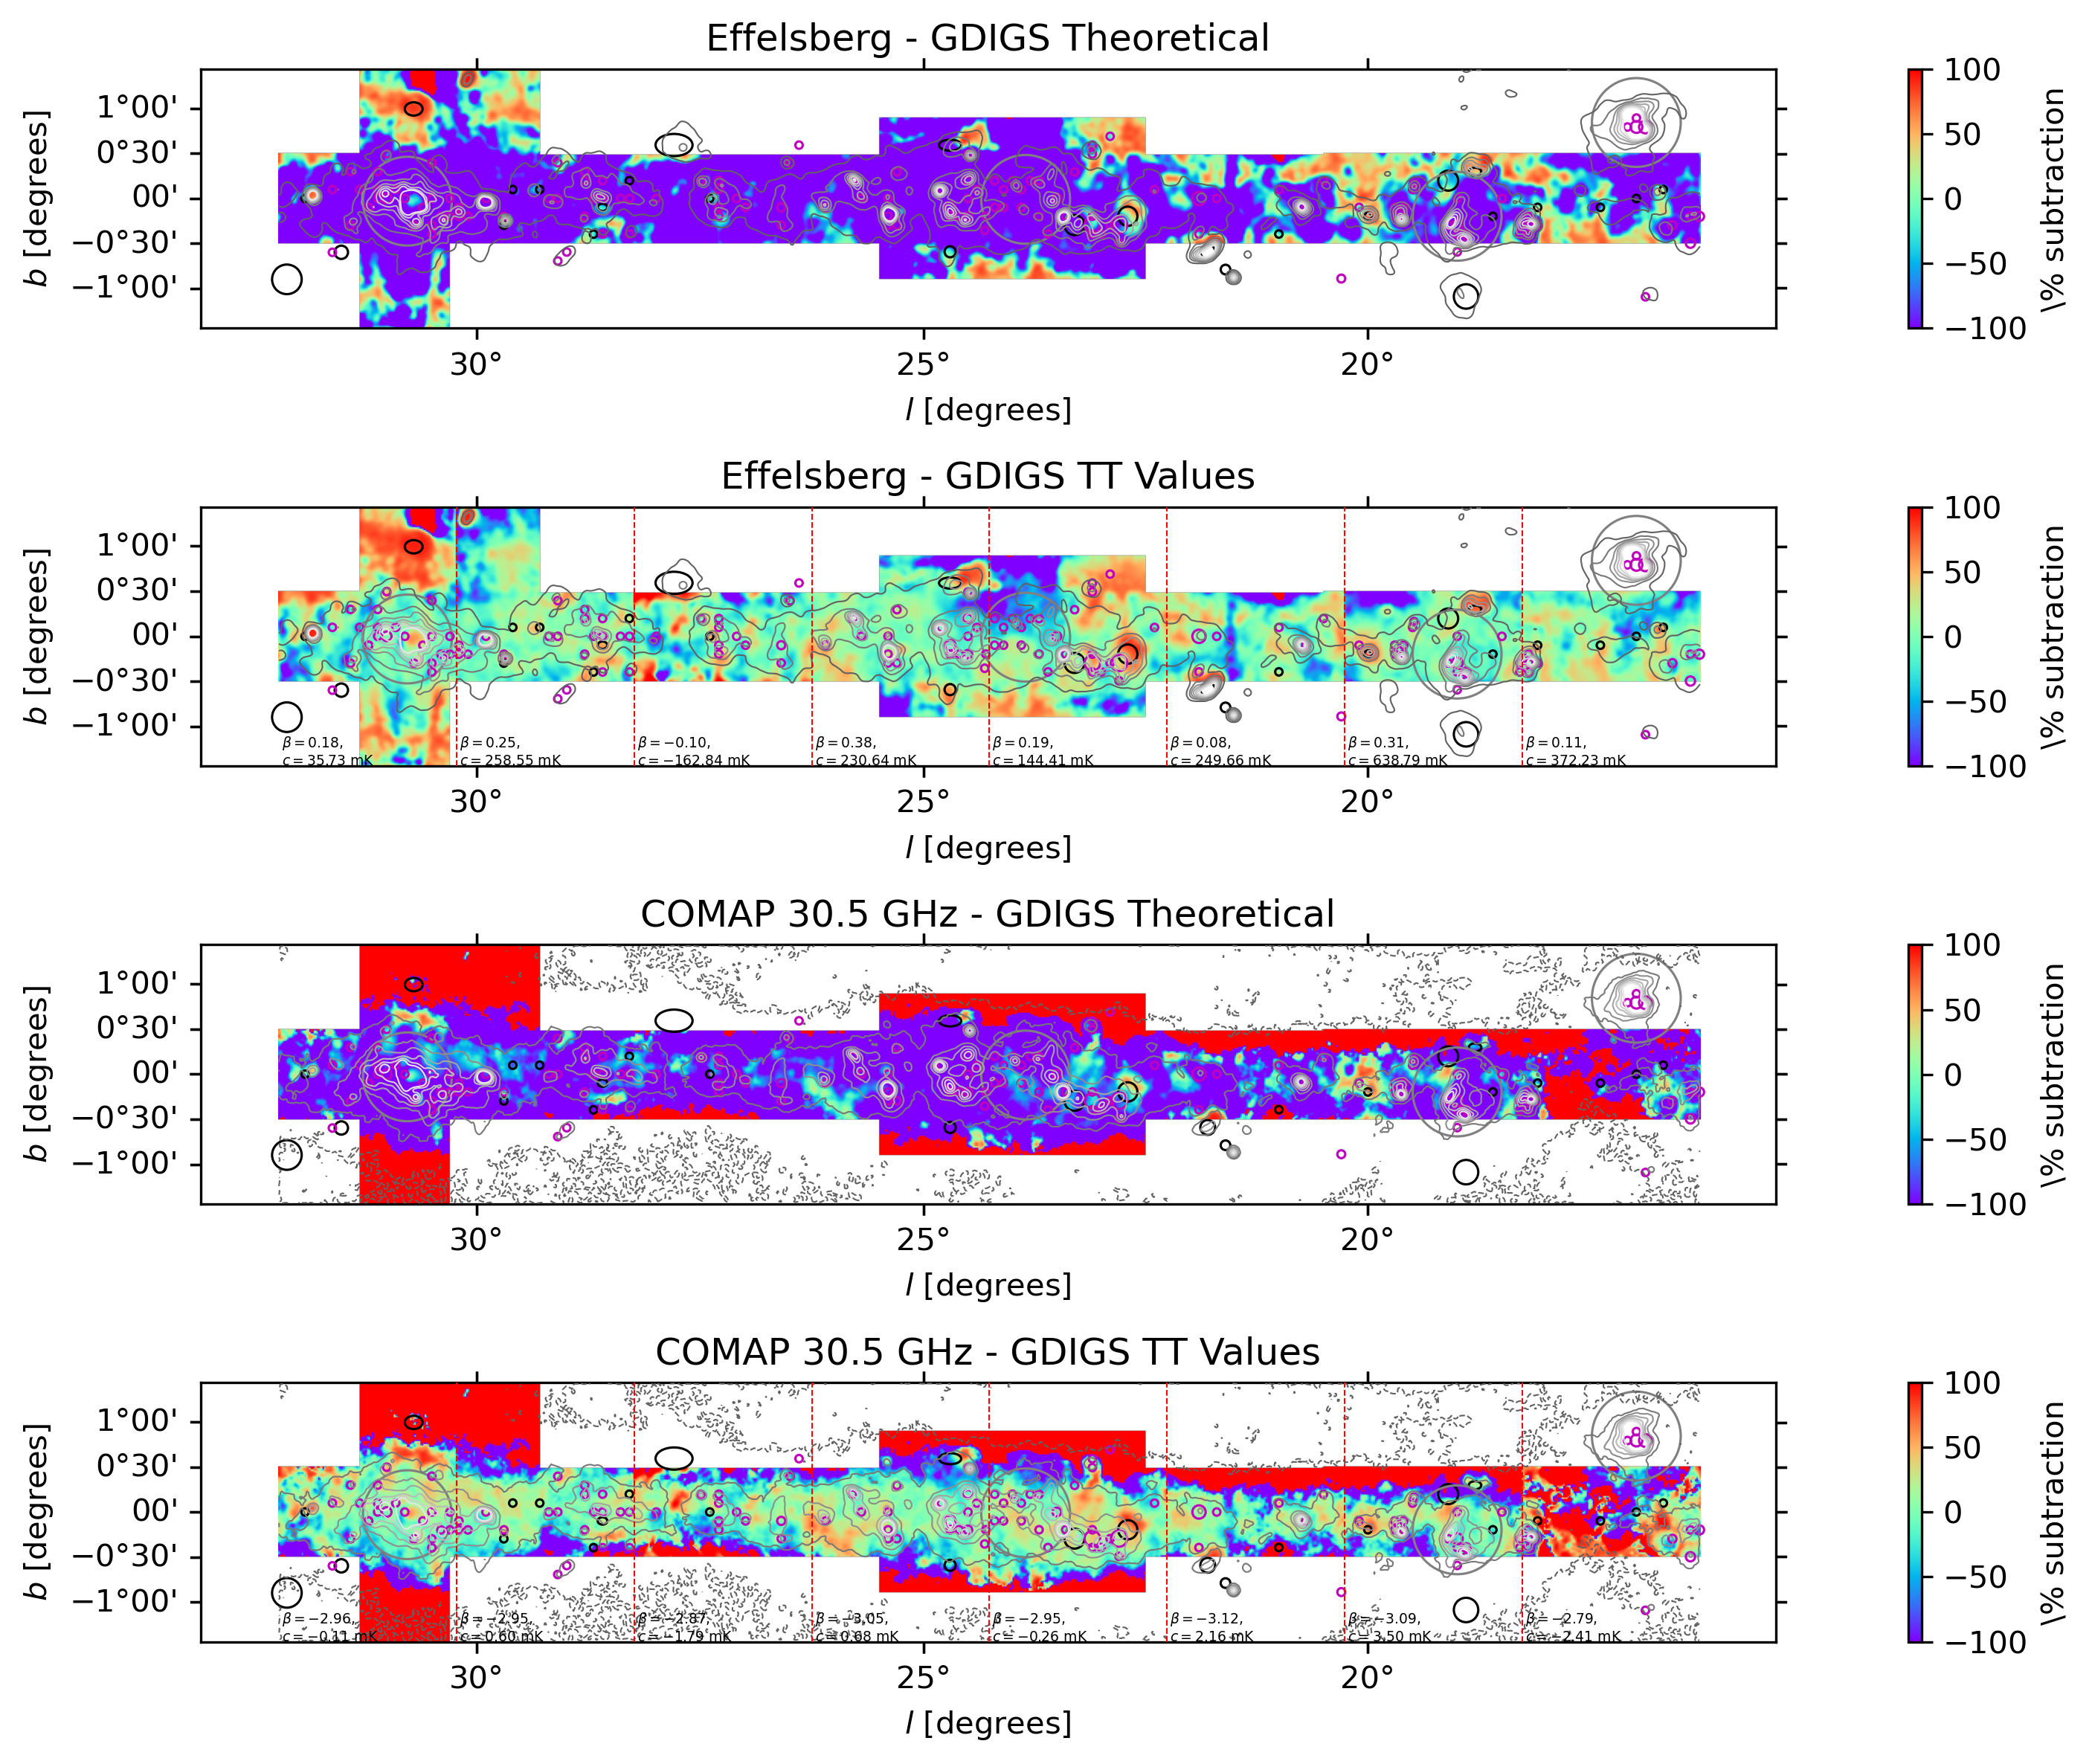

In [ ]:
# Theoretical GDIGs difference maps

# -----------------

def gaunt_factor_stuart(freq, elec_temp):
    pi = constants.pi
    e = 2.718281828
    exponent = 5.960 - ((np.sqrt(3) / pi) * np.log((freq/(10**(9)) * (elec_temp/(10**4))**(-1.5))))
    # exponent = 5.960 - ((np.sqrt(3)/pi) * np.log((freq * (elec_temp*(10**4))**(-1.5))))
    # print(exponent)
    # print(e)
    return np.log(e**(exponent) + e)


def gaunt_factor_thomas(freq, elec_temp):
    pi = constants.pi
    e = 2.718281828
    exponent = 5.960 - ((np.sqrt(3) / pi) * np.log((freq/(10**(9)) * (elec_temp/(10**4))**(-1.5))))
    # exponent = 5.960 - ((np.sqrt(3)/pi) * np.log((freq * (elec_temp*(10**4))**(-1.5))))
    # print(exponent)
    # print(e)
    return np.log(e**(exponent) + e)


def optdepth_ff_thomas(freq, Elec_temp, EM):
    pre_factor = 5.468*10**(-2)
    return pre_factor * (Elec_temp)**(-1.5) * (freq/(10**9))**(-2) * EM * gaunt_factor_thomas(freq, Elec_temp)
    # return A*(Elec_temp)**(-1.5) * (freq)**(-2) * EM * gaunt_factor(freq, Elec_temp)

# Alternative forms from https://www.cv.nrao.edu/~sransom/web/Ch4.html:
# def gaunt_factor(freq, elec_temp): # Electron Temperature in K
#     freq_term = 4.955*10**(-2) * (freq/10**9)**(-1)
#     temp_term = 1.5 * np.log(elec_temp)
#     # exponent = 5.960 - ((np.sqrt(3)/pi) * np.log((freq * (elec_temp/(10**4))**(-1.5))))
#     # print(e**exponent)
#     # print(e)
#     return np.log(freq_term) + temp_term


# def optdepth_ff(freq, Elec_temp, EM): # Electron Temperature in K
#     A = 3.014*10**(-2)
#     return A*(Elec_temp)**(-1.5) * (freq/(10**9))**(-2) * EM * gaunt_factor(freq, Elec_temp)
#     # return A*(Elec_temp)**(-1.5) * (freq)**(-2) * EM * gaunt_factor(freq, Elec_temp)

#------------------------

def EM_ff(int_lineem, elec_temp):
    return 6.39 * int_lineem * ((elec_temp)/(8*10**(6)))**(1.5) # mK km/s


def get_difftemplate(limap, freq, electron_temp, EM_eq="GDIGS", ff_eq="Thomas"):
    e = 2.718281828
    EM = EM_ff(limap, electron_temp)
    if ff_eq == "Stuart": # From Stuart's paper
        T_ff = 5.468*10**(-2) * (electron_temp/1000)**(-0.5) * (freq/(10**9))**(-2) * EM_ff(limap, electron_temp) * gaunt_factor_stuart(freq, electron_temp/1000)
        return T_ff * 1000
    elif ff_eq == "Thomas":
        optical_depth = optdepth_ff_thomas(freq, electron_temp/1000, EM)
        print(f"Mean Optical Depth = {np.nanmean(optical_depth)}")
        depth_scale = 1 - e**(-optical_depth)
        return electron_temp*depth_scale
        # elif ff_eq=="Alves":
    #     prefactor = 8.235 * 10**(-2)


ELECTRON_TEMPERATURE = 8*10**6 # mK

GDIGs_mosaic_path = "/home/u20482jg/MPHYS_Project_Local/data/all_maps/maps/gdigs_moment0_mosaic_1arcmin.fits"
GDIGs_mapname = "GDIGS Moment 0"

GDIGs_FWHM = 2.65

ref_mapdict = (
EFFELSBERG_MAPS |\
NOBEYAMA_MAPS |\
# GDIGS_MAPS |\
COMAP_MAPS)
ref_mapkeys = list(ref_mapdict.keys())

SMOOTHING_FWHM = 5

# subt_fname, subt_freq, subt_FWHM, subt_err = get_map_info(subt_mapname)
subt_map, subt_header, subt_wcs = get_map(GDIGs_mosaic_path)
subt_map, subt_wcs, _ = cut_data(subt_map, subt_wcs, subt_header, GDIGs_mapname)
subt_map_unsmooth = convert_to_mK(GDIGs_mapname, subt_map, subt_freq) # or mK kms^-1 for GDIGS

smoothing_kernel = Gaussian2DKernel(x_stddev=sigma(GDIGs_FWHM, SMOOTHING_FWHM, 1))
subt_map = convolve(subt_map_unsmooth, smoothing_kernel, preserve_nan=True)

subt_maprepix, subt_wcsrepix, subt_headerrepix = rebin_map(subt_map, subt_header, factor=5) # Using Header

GDIGS_diffmaps = {}
GDIGS_diffmapsrepix = {}
refmaps_datadict = {}
theorval_fileout = np.array(ref_mapkeys.copy(), dtype=str)
means_row = np.zeros_like(theorval_fileout)
stds_row = np.zeros_like(theorval_fileout)
for i, refkey in enumerate(ref_mapdict):
    refmap_fname, refmap_freq, refmap_FWHM, refmap_err = get_map_info(refkey)
    ref_map, ref_header, ref_wcs = get_map(f"{MAPS_DIRECTORY}/{refmap_fname}")
    ref_map, ref_wcs, _ = cut_data(ref_map, ref_wcs, ref_header, refkey)
    ref_map = convert_to_mK(refkey, ref_map, refmap_freq)

    # if subt_mapname in GDIGS_MAPS.keys():
    #     subt_map_conv = JyPersr_to_K(subt_map, refmap_freq)

    smoothing_kernel = Gaussian2DKernel(x_stddev=sigma(refmap_FWHM, SMOOTHING_FWHM, 1))
    ref_map = convolve(ref_map, smoothing_kernel, preserve_nan=True)
    ref_maprepix, ref_mapwcsrepix, ref_mapheaderrepix = rebin_map(ref_map, ref_header, factor=5) # Using Header
    print(refkey)

    smoothing_kernel = Gaussian2DKernel(x_stddev=sigma(GDIGS_FWHM, SMOOTHING_FWHM, 1))
    diff_template_unsmooth = get_difftemplate(subt_map_unsmooth, refmap_freq, ELECTRON_TEMPERATURE)

    diff_template = convolve(diff_template_unsmooth, smoothing_kernel, preserve_nan=True)
    diff_templaterepix, _, _ = rebin_map(diff_template, ref_header, factor=5) # Using Header
    theor_m = diff_template_unsmooth/subt_map_unsmooth
    meantheor_m = np.nanmean(theor_m)
    stdtheor_m = np.nanstd(theor_m)
    print(f"Theoretical Gradient value: {meantheor_m} +/- {stdtheor_m}(random) +/- 50% (systematic)")
    means_row[i] = str(meantheor_m)
    stds_row[i] = str(stdtheor_m)

    refmaps_datadict[refkey] = ref_map

    if diff_template.shape != ref_map.shape:
        diff_templatecol = diff_template.shape[0]
        ref_mapcol = ref_map.shape[0]
        diff_templaterow = diff_template.shape[1]
        ref_maprow = ref_map.shape[1]
        diff_template = diff_template[:np.min([diff_templatecol,ref_mapcol]),:np.min([diff_templaterow,ref_maprow])]
        ref_map = ref_map[:np.min([diff_templatecol,ref_mapcol]),:np.min([diff_templaterow,ref_maprow])]

    GDIGS_diffmaps[' - '.join([refkey,'free-free template'])] = diff_template
    GDIGS_diffmaps[' - '.join([refkey,'template subtracted'])] = (ref_map - diff_template) / ref_map * 100
    GDIGS_diffmapsrepix[' - '.join([refkey,'free-free template'])] = diff_templaterepix
    GDIGS_diffmapsrepix[' - '.join([refkey,'template subtracted'])] = ref_maprepix - diff_templaterepix


theorval_fileout = np.vstack((theorval_fileout, means_row))
theorval_fileout = np.vstack((theorval_fileout, stds_row))

np.savetxt(f"{THEORVALSPREFIX}.csv", theorval_fileout, fmt='%s', delimiter=',')


snr_ls, snr_bs, snr_xr, snr_yr = find_SNRs("/home/u20482jg/MPHYS_Project_Local/data/SNR_locations_final.csv")
ame_ls, ame_bs = get_ame_locs("/home/u20482jg/MPHYS_Project_Local/results_files/R_Cepeda_Arroita_2025_AME_Synthcat.dat")
h2_ls, h2_bs, h2_ds, _ = get_Paladini_data("/home/u20482jg/MPHYS_Project_Local/data/Paladini2003_syntheticasu.tsv")

snr_ls = np.array(snr_ls, dtype=float)
snr_bs = np.array(snr_bs, dtype=float)
ame_ls = np.array(ame_ls, dtype=float)
ame_bs = np.array(ame_bs, dtype=float)
h2_ls = np.array(h2_ls, dtype=float)
h2_bs = np.array(h2_bs, dtype=float)
h2_ds = np.array(h2_ds, dtype=float)

# snr_ls, snr_bs = galactic_to_pixel(snr_ls, snr_bs, ref_wcs)
# ame_ls, ame_bs = galactic_to_pixel(ame_ls, ame_bs, ref_wcs)

coordsdict = {}
coordsdict['black'] = (snr_ls, snr_bs, snr_xr, snr_yr)
coordsdict['grey'] = (ame_ls, ame_bs, np.ones_like(ame_ls)*60, np.ones_like(ame_bs)*60)
coordsdict['m'] = (h2_ls, h2_bs, h2_ds/2, h2_ds/2)

# plot_fits_multi(GDIGS_diffmaps, subt_wcs, coords_dict = coordsdict,
#                 contour_mapdict=None, n_contours=0, perc_ranges=(0.0, 99.9),
#                 decoratorsdict=None, decorator_locsdict=None,
#                 title=f"Difference maps with {subt_mapname} subtracted")

# plot_fits_multi(GDIGS_diffmapsrepix, subt_wcsrepix, coords_dict = coordsdict,
#                 contour_mapdict=None, n_contours=0, perc_ranges=(0.0, 100),
#                 decoratorsdict=None, decorator_locsdict=None,
#                 title=f"Difference maps with {subt_mapname} subtracted")

comparison_dict = {
    "Effelsberg - GDIGS Theoretical": GDIGS_diffmaps['Effelsberg 2.73 GHz (5 amin) - template subtracted'],
    "Effelsberg - GDIGS TT Values": diffmaps_dict['Effelsberg 2.73 GHz (5 amin)'],
    "COMAP 30.5 GHz - GDIGS Theoretical": GDIGS_diffmaps['COMAP 30.5 GHz - template subtracted'],
    "COMAP 30.5 GHz - GDIGS TT Values": diffmaps_dict['COMAP 30.5 GHz']
}

comparisontextboxstrs_dict = {
    "Effelsberg - GDIGS Theoretical": None,
    "Effelsberg - GDIGS TT Values": textstrs_dict['Effelsberg 2.73 GHz (5 amin)'],
    "COMAP 30.5 GHz - GDIGS Theoretical": None,
    "COMAP 30.5 GHz - GDIGS TT Values": textstrs_dict['COMAP 30.5 GHz']
}

comparisontextboxlocs_dict = {
    "Effelsberg - GDIGS Theoretical": None,
    "Effelsberg - GDIGS TT Values": textlocs_dict['Effelsberg 2.73 GHz (5 amin)'],
    "COMAP 30.5 GHz - GDIGS Theoretical": None,
    "COMAP 30.5 GHz - GDIGS TT Values": textlocs_dict['COMAP 30.5 GHz']
}

comparisontracers_dict = {
    "Effelsberg - GDIGS Theoretical": refmaps_datadict['Effelsberg 2.73 GHz (5 amin)'],
    "Effelsberg - GDIGS TT Values": refmaps_datadict['Effelsberg 2.73 GHz (5 amin)'],
    "COMAP 30.5 GHz - GDIGS Theoretical": refmaps_datadict['COMAP 30.5 GHz'],
    "COMAP 30.5 GHz - GDIGS TT Values": refmaps_datadict['COMAP 30.5 GHz']
}


plot_fits_multi(comparison_dict, subt_wcs, coords_dict = coordsdict,
                contour_mapdict=comparisontracers_dict, n_contours=8, perc_ranges=(0.0, 99.5),
                decoratorsdict=comparisontextboxstrs_dict, decorator_locsdict=comparisontextboxlocs_dict,
                title=f"Difference maps comparisons with theoretical", cbar_label=r'\% subtraction')